# **Importing libraries and Unpacking the dataset**



In [ ]:
# !git clone https://github.com/willowsierra/recvis24_a3

In [ ]:
# %cd recvis24_a3
# !pip install -r requirements.txt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip '/content/drive/MyDrive/MVA/OR/mva-recvis-2024.zip' -d .

Streaming output truncated to the last 5000 lines.
  inflating: ./sketch_recvis2024/sketch_recvis2024/train_images/n04447861/img_irxkb.jpeg  
  inflating: ./sketch_recvis2024/sketch_recvis2024/train_images/n04447861/img_jzos8.jpeg  
  inflating: ./sketch_recvis2024/sketch_recvis2024/train_images/n04447861/img_kbikw.jpeg  
  inflating: ./sketch_recvis2024/sketch_recvis2024/train_images/n04447861/img_kc8gy.jpeg  
  inflating: ./sketch_recvis2024/sketch_recvis2024/train_images/n04447861/img_ks1m4.jpeg  
  inflating: ./sketch_recvis2024/sketch_recvis2024/train_images/n04447861/img_le2nt.jpeg  
  inflating: ./sketch_recvis2024/sketch_recvis2024/train_images/n04447861/img_m0ptr.jpeg  
  inflating: ./sketch_recvis2024/sketch_recvis2024/train_images/n04447861/img_n4da4.jpeg  
  inflating: ./sketch_recvis2024/sketch_recvis2024/train_images/n04447861/img_o7xu6.jpeg  
  inflating: ./sketch_recvis2024/sketch_recvis2024/train_images/n04447861/img_ou994.jpeg  
  inflating: ./sketch_recvis2024/sketch

Setup: Import Libraries

In [ ]:
import argparse
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# **Define the model**

In [ ]:
!pip install timm

In [ ]:
from timm import create_model

class SwinTransformerWithDropout(nn.Module):
  def __init__(self, num_classes=500, dropout_rate=0.3):
    super(SwinTransformerWithDropout, self).__init__()
    # Load pretrained Swin-Base Transformer
    self.model = create_model(
        "swin_base_patch4_window7_224",
        pretrained=True,
        num_classes=0,
    )
    # Add a new classification head with dropout
    in_features = self.model.num_features
    self.head = nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(in_features, num_classes)
    )

  def forward(self, x):
    features = self.model(x)
    return self.head(features)

# **Training, Validation, and Evaluation functions**

In [ ]:
def train(model, optimizer, train_loader, epoch, log_interval=10):
  model.train()
  correct = 0
  total_loss = 0

  for batch_idx, (data, target) in enumerate(train_loader):

    data, target = data.to(device), target.to(device)

    # Zero gradients
    optimizer.zero_grad()
    output = model(data)
    # Compute loss
    criterion = nn.CrossEntropyLoss()
    loss = criterion(output, target)
    total_loss += loss.item()
    # Backward pass
    loss.backward()
    optimizer.step()
    # scheduler.step()
    # Predictions and batch accuracy
    pred = output.argmax(dim=1, keepdim=True)
    correct_batch = pred.eq(target.view_as(pred)).sum().item()
    correct += correct_batch

    # Log the progress
    if batch_idx % log_interval == 0:
      print(f"Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} "
            f"({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}")

  # Epoch accuracy and average loss
  epoch_accuracy = 100. * correct / len(train_loader.dataset)
  avg_loss = total_loss / len(train_loader)
  print(f"\nTrain set: Average Loss: {avg_loss:.6f}, Accuracy: {correct}/{len(train_loader.dataset)} "
        f"({epoch_accuracy:.2f}%)")

  return avg_loss, epoch_accuracy

def validate(model, val_loader):
  model.eval()
  validation_loss = 0
  correct = 0
  criterion = nn.CrossEntropyLoss()

  with torch.no_grad():
    for data, target in val_loader:

      data, target = data.to(device), target.to(device)
      # Forward pass
      output = model(data)
      validation_loss += criterion(output, target).item()
      # Predictions and accuracy
      pred = output.argmax(dim=1, keepdim=True)
      correct += pred.eq(target.view_as(pred)).sum().item()

  # Average loss and accuracy
  avg_validation_loss = validation_loss / len(val_loader)
  accuracy = 100. * correct / len(val_loader.dataset)
  print(f"\nValidation set: Average loss: {avg_validation_loss:.4f}, Accuracy: {correct}/{len(val_loader.dataset)} "
        f"({accuracy:.2f}%)")

  return avg_validation_loss, accuracy

# **Data preparation and Model initialization for training**

In [ ]:
data_dir = "sketch_recvis2024/sketch_recvis2024"
# Set parameters
batch_size = 64
epochs = 20
learning_rate = 3*1e-4

# Initialize model
model = SwinTransformerWithDropout(num_classes=500, dropout_rate=0.3).to(device)

# Transformations for train set and validation set

train_transforms = transforms.Compose([
    # transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.2),
    transforms.RandomAffine(degrees=20, translate=(0.2, 0.2), scale=(0.8, 1.2)),
    transforms.RandomPerspective(distortion_scale=0.6, p=0.5),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.33)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load data
train_loader = DataLoader(
    datasets.ImageFolder(os.path.join(data_dir, "train_images"), transform= train_transforms),
    batch_size=batch_size, shuffle=True, num_workers=4
)
val_loader = DataLoader(
    datasets.ImageFolder(os.path.join(data_dir, "val_images"), transform= val_transforms),
    batch_size=batch_size, shuffle=False, num_workers=4
)

# Set up optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

from transformers import get_scheduler

total_training_steps = len(train_loader) * epochs

Set up scheduler with warmup + cosine decay
scheduler = get_scheduler(
    "cosine",                      # Cosine annealing
    optimizer=optimizer,
    num_warmup_steps=10,           # Warmup for the first 10 steps
    num_training_steps=total_training_steps
)

# **Training and Plots**

In [ ]:
# Lists for Accuracy and Loss graphs
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_accuracy = 0.0

# Training and validation loop
for epoch in range(1, epochs + 1):
  # Training step
  train_loss, train_accuracy = train(model, optimizer, train_loader, epoch)
  train_losses.append(train_loss)
  train_accuracies.append(train_accuracy)

  # Validation step
  val_loss, val_accuracy = validate(model, val_loader)
  val_losses.append(val_loss)
  val_accuracies.append(val_accuracy)

  # Check if this is the best validation accuracy, if so, save the model
  if val_accuracy > best_val_accuracy:
    best_val_accuracy = val_accuracy
    torch.save(model.state_dict(), "best_model.pth")
    print(f"New best model saved with validation accuracy: {best_val_accuracy:.2f}%")

Train Epoch: 1 [0/20000 (0%)]	Loss: 6.294299
Train Epoch: 1 [640/20000 (3%)]	Loss: 6.182793
Train Epoch: 1 [1280/20000 (6%)]	Loss: 6.215472
Train Epoch: 1 [1920/20000 (10%)]	Loss: 6.223936
Train Epoch: 1 [2560/20000 (13%)]	Loss: 6.142642
Train Epoch: 1 [3200/20000 (16%)]	Loss: 6.063779
Train Epoch: 1 [3840/20000 (19%)]	Loss: 5.954695
Train Epoch: 1 [4480/20000 (22%)]	Loss: 5.808860
Train Epoch: 1 [5120/20000 (26%)]	Loss: 5.766394
Train Epoch: 1 [5760/20000 (29%)]	Loss: 5.465248
Train Epoch: 1 [6400/20000 (32%)]	Loss: 5.304872
Train Epoch: 1 [7040/20000 (35%)]	Loss: 4.584630
Train Epoch: 1 [7680/20000 (38%)]	Loss: 4.316766
Train Epoch: 1 [8320/20000 (42%)]	Loss: 4.483657
Train Epoch: 1 [8960/20000 (45%)]	Loss: 4.231747
Train Epoch: 1 [9600/20000 (48%)]	Loss: 4.411716
Train Epoch: 1 [10240/20000 (51%)]	Loss: 3.872204
Train Epoch: 1 [10880/20000 (54%)]	Loss: 3.784713
Train Epoch: 1 [11520/20000 (58%)]	Loss: 3.671132
Train Epoch: 1 [12160/20000 (61%)]	Loss: 3.983845
Train Epoch: 1 [12800/2

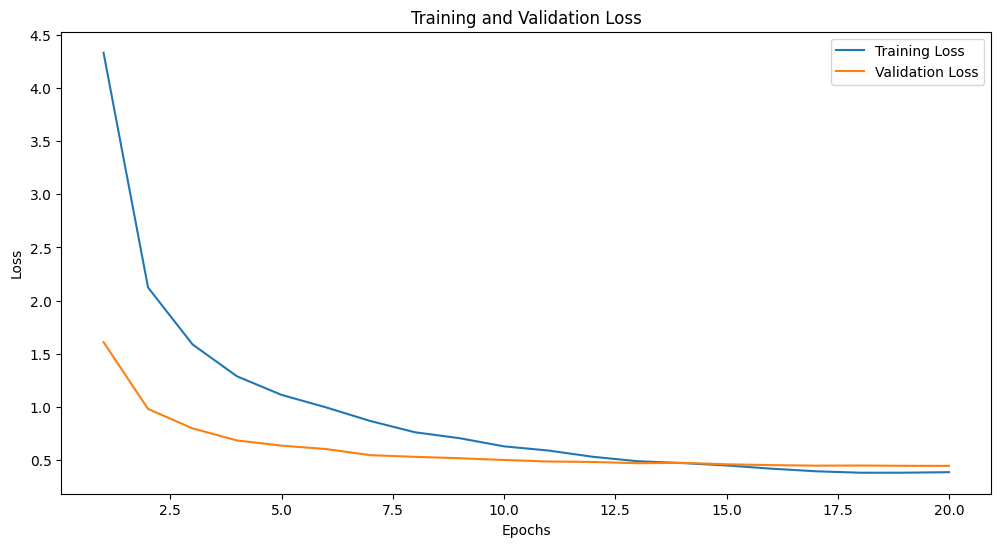

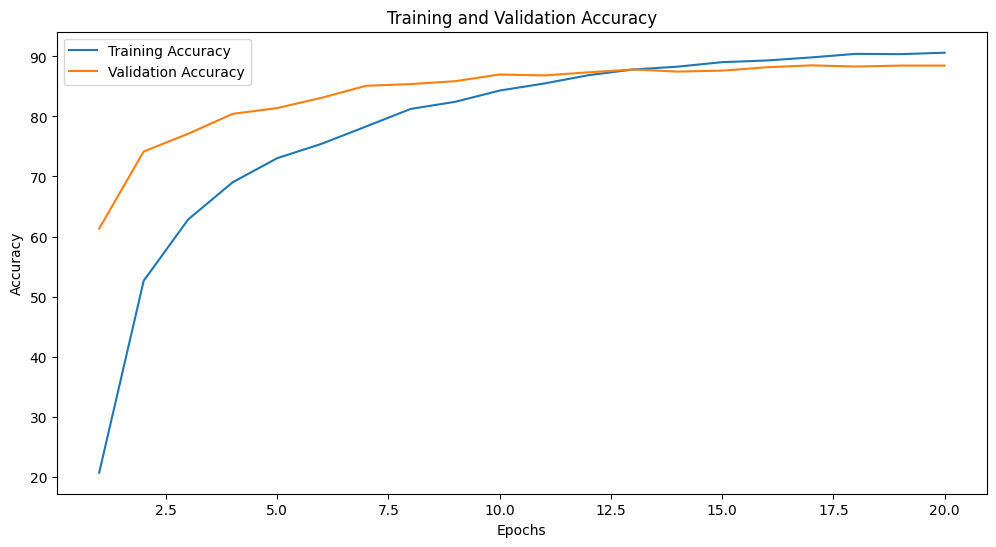

In [ ]:
epochs_range = range(1, epochs + 1)

# Plot training and validation Loss
plt.figure(figsize=(12, 6))
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Plot training and validation Accuracy
plt.figure(figsize=(12, 6))
plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# **Kaggle file**

In [ ]:
from tqdm import tqdm
from PIL import Image

# All the paths
data_dir = "/content/sketch_recvis2024/sketch_recvis2024"
test_dir = os.path.join(data_dir, "test_images/mistery_category")
model_path = "best_model.pth"
output_file_path = "kaggle.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# If we want to load the weight

# model = SwinTransformerModelWithDropout(num_classes=500).to(device)

# # Load the saved model weights
# state_dict = torch.load(model_path, map_location=device)
# model.load_state_dict(state_dict)
# model.to(device)

# Function to load images
def pil_loader(path):
    with open(path, 'rb') as f:
        img = Image.open(f)
        return img.convert('RGB')


data_transforms = val_transforms

model.eval()

# Open output file for writing
with open(output_file_path, "w") as output_file:
  output_file.write("Id,Category\n")

  # Iterate through test images
  for f in tqdm(os.listdir(test_dir)):
    if "jpeg" in f:
      data = data_transforms(pil_loader(os.path.join(test_dir, f)))
      data = data.unsqueeze(0).to(device)

      # Make prediction
      output = model(data)
      pred = output.argmax(dim=1, keepdim=True).item()

      # Write to output file
      output_file.write(f"{f[:-5]},{pred}\n")

print(f"Successfully wrote {output_file_path}, you can upload this file to the Kaggle competition website")

100%|██████████| 5455/5455 [03:49<00:00, 23.80it/s]

Successfully wrote kaggle.csv, you can upload this file to the Kaggle competition website
